In [215]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Lettura dei dati

In [216]:
df = pd.read_csv("../data/processed/athlete_events_processed.csv")
df.head()

,ID,Name,Sex,Age,Height,Weight,NOC,Year,Season,City,Sport,Event,Medal_Bronze,Medal_Gold,Medal_None,Medal_Silver
0,1,A Dijiang,M,24.0,180.0,80.0,CHN,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,0,0,1,0
1,2,A Lamusi,M,23.0,170.0,60.0,CHN,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,0,0,1,0
2,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,NED,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,0,0,1,0
3,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,NED,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",0,0,1,0
4,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,NED,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,0,0,1,0


Analisi della cardinalità delle variabili categoriali

In [217]:
# Selezioniamo le colonne categoriali principali in df_moderno
colonne_categoriali = ['Sex', 'Season', 'City', 'Sport', 'NOC', 'Event','Year']

# Calcoliamo la cardinalità (numero di valori unici) per ciascuna
cardinalita = df[colonne_categoriali].nunique().sort_values(ascending=False)

print("--- Cardinalità (Valori Unici) su df_moderno (1960-oggi) ---")
print(cardinalita)

--- Cardinalità (Valori Unici) su df_moderno (1960-oggi) ---
Event     489
NOC       223
Sport      51
City       29
Year       21
Sex         2
Season      2
dtype: int64


Preparazione del dataframe per classificazione e clustering

In [218]:
from sklearn.preprocessing import MinMaxScaler

cols_to_drop = ['Sport', 'Event', 'City', 'NOC', 'Year', 'ID', 'Name']

df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Colonne rimosse (se presenti): {', '.join(cols_to_drop)}")

cols_to_ohe = ['Sex', 'Season']

# Applichiamo OHE (con drop_first=True per evitare ridondanza)
df = pd.get_dummies(df, columns=cols_to_ohe, dtype=int, drop_first=False)

print("Applicato OHE a 'Sex' e 'Season' (drop_first=True).")

numeric_features_to_scale = ['Age', 'Height', 'Weight']

print(f"--- Scaling 'in-place' (sovrascrittura) di: {', '.join(numeric_features_to_scale)} ---")

# --- 2. INIZIALIZZAZIONE E APPLICAZIONE DELLO SCALER ---
scaler = MinMaxScaler()


df[numeric_features_to_scale] = scaler.fit_transform(df[numeric_features_to_scale])

print("Scaling 'in-place' completato.")

# --- 4. VERIFICA ---
print("\nVerifica statistiche colonne scalate (Media ~0, Dev. Std. ~1):")
print(df[numeric_features_to_scale].describe())

print("\nHead del DataFrame finale (scalato):")
df.head()

Colonne rimosse (se presenti): Sport, Event, City, NOC, Year, ID, Name
Applicato OHE a 'Sex' e 'Season' (drop_first=True).
--- Scaling 'in-place' (sovrascrittura) di: Age, Height, Weight ---
Scaling 'in-place' completato.

Verifica statistiche colonne scalate (Media ~0, Dev. Std. ~1):
                 Age         Height         Weight
count  209072.000000  209072.000000  209072.000000
mean        0.232703       0.488584       0.241615
std         0.091231       0.105781       0.075290
min         0.000000       0.000000       0.000000
25%         0.166667       0.414141       0.190476
50%         0.216667       0.484848       0.238095
75%         0.283333       0.555556       0.285714
max         1.000000       1.000000       1.000000

Head del DataFrame finale (scalato):


,Age,Height,Weight,Medal_Bronze,Medal_Gold,Medal_None,Medal_Silver,Sex_F,Sex_M,Season_Summer,Season_Winter
0,0.216667,0.535354,0.291005,0,0,1,0,0,1,1,0
1,0.200000,0.434343,0.185185,0,0,1,0,0,1,1,0
2,0.166667,0.585859,0.301587,0,0,1,0,1,0,0,1
3,0.166667,0.585859,0.301587,0,0,1,0,1,0,0,1
4,0.233333,0.585859,0.301587,0,0,1,0,1,0,0,1


Calcolo e visualizzazione matrice di correlazione

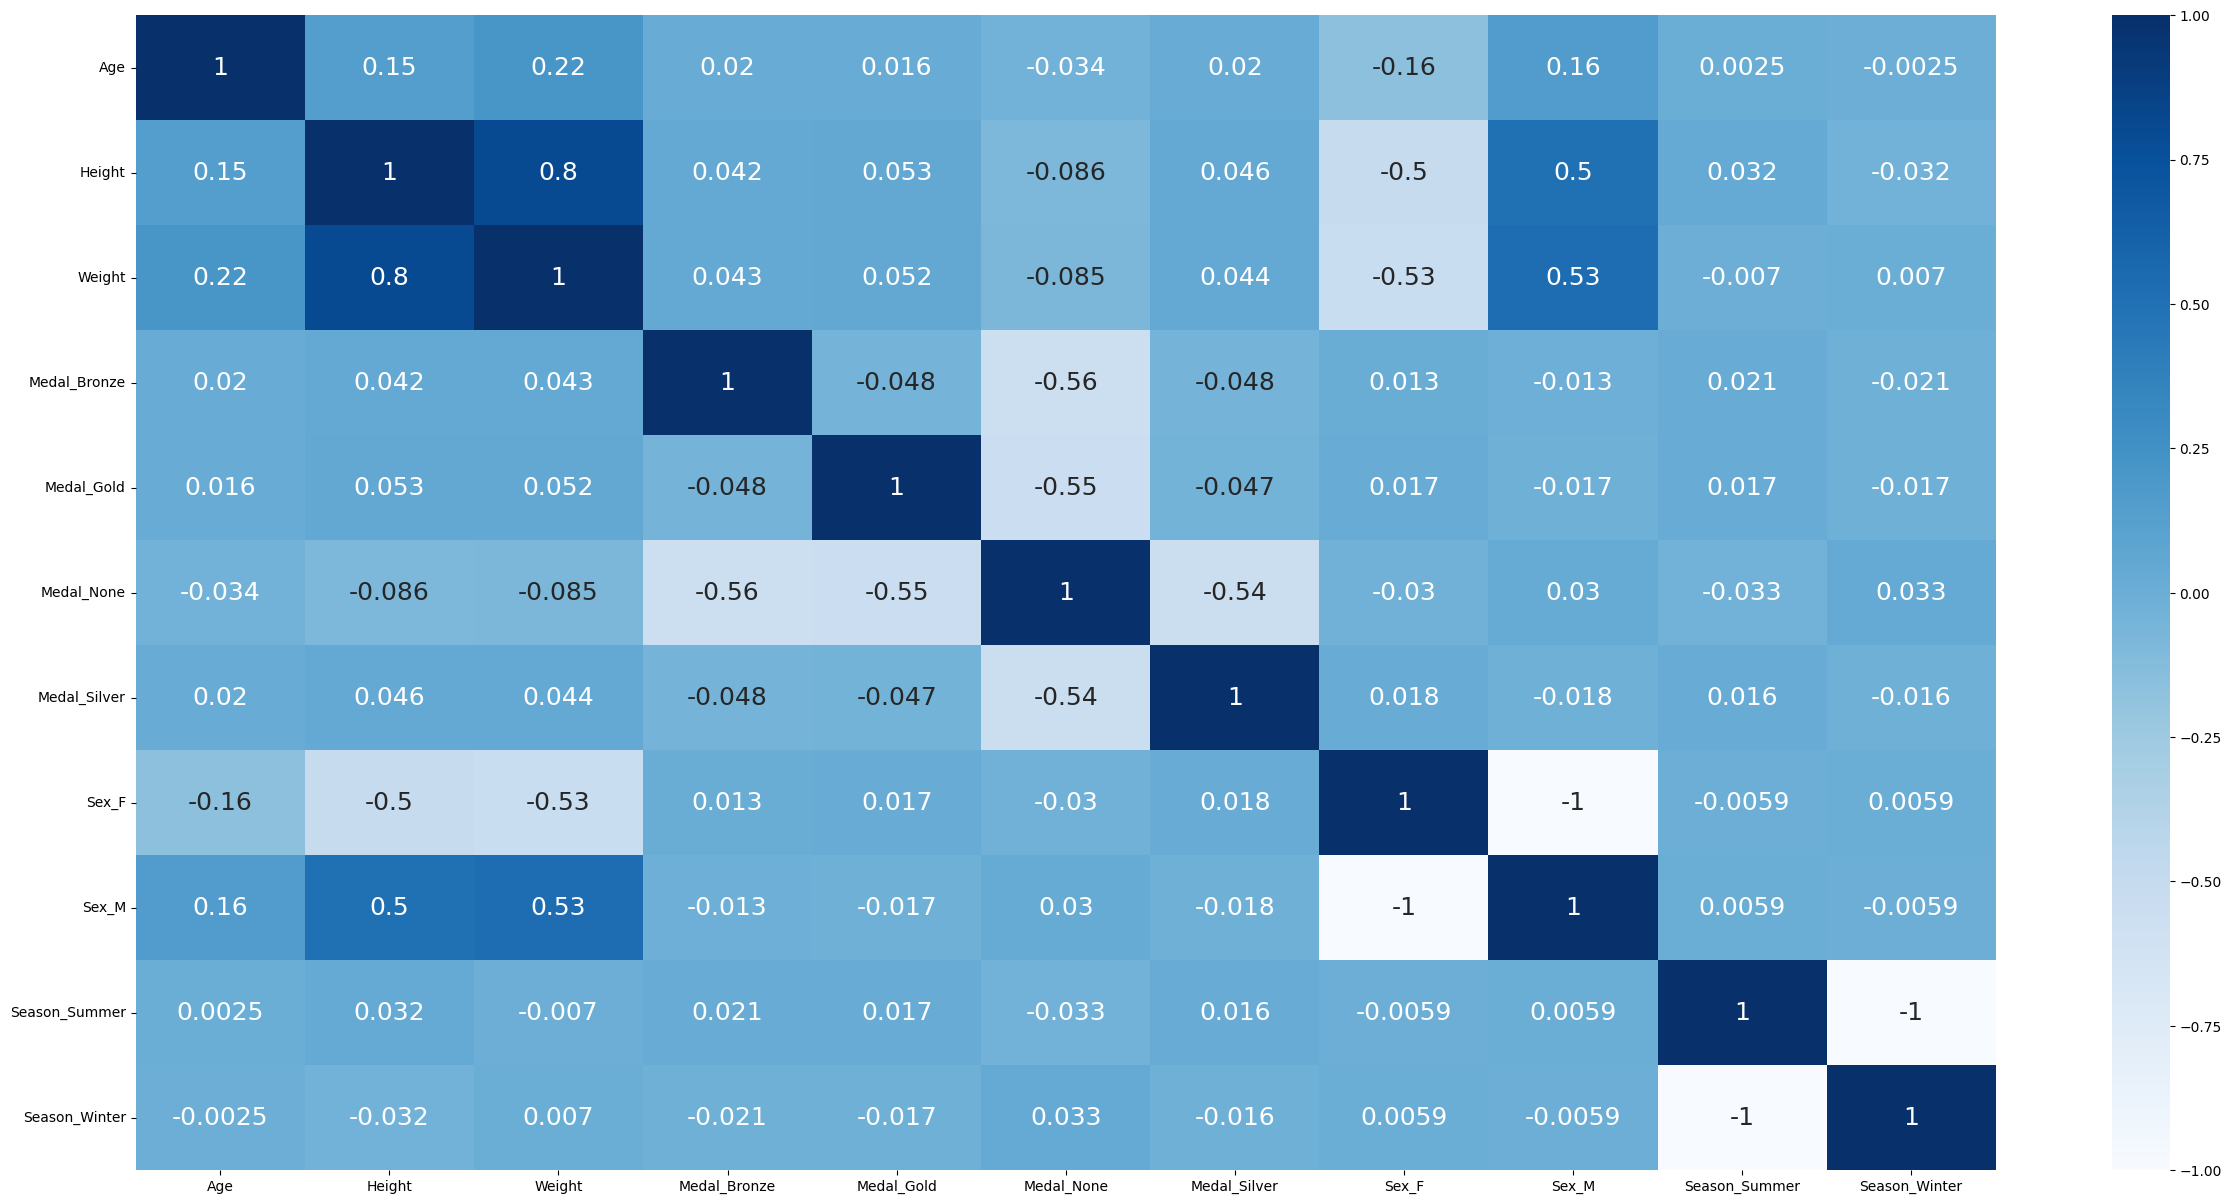

In [219]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(30,15))
ax = sns.heatmap(df[df.columns].corr(),cmap="Blues",annot=True,annot_kws={"size": 18})

Dalla matrice di correlazione si nota una **multicollinearità** perfetta tra i campi Sex_F e Sex_M e lo stesso per i campi Season_Winter e Season_Summer, quindi vengono rimosse le colonne Sex_F e Season_Winter.
Viene rimossa anche la colonna Medal_None in quantose un atleta non vince nè oro, nè argento, nè bronzo allora certamente Medal_None sarà a 1.
Inoltre, si nota una forte correlazione tra Height e Weight, quindi attraverso un processo di feature engineering si sceglie di usare come feature il BMI (Body Mass Index) che si calcola:

BMI = Peso (kg) / Altezza^2 (m)

E si tengono BMI e Height come features.

In [220]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Carica i dati puliti (ma non scalati)
df_final = pd.read_csv('../data/processed/athlete_events_processed.csv') 

cols_to_drop = ['Sport', 'Event', 'City', 'NOC', 'Year', 'ID', 'Name']

df_final = df_final.drop(columns=cols_to_drop, errors='ignore')

print(f"Colonne rimosse (se presenti): {', '.join(cols_to_drop)}")

cols_to_ohe = ['Sex', 'Season']

# Applichiamo OHE (con drop_first=True per evitare ridondanza)
df_final = pd.get_dummies(df_final, columns=cols_to_ohe, dtype=int, drop_first=False)
df_final = df_final.drop(columns=['Sex_F', 'Season_Winter', 'Medal_None'], errors='ignore')

# 2. Calcola il BMI (Feature Engineering)
df_final['Height_m'] = df_final['Height'] / 100  # Converti da cm a m
df_final['BMI'] = df_final['Weight'] / (df_final['Height_m']**2)

# Pulisci eventuali valori infiniti se Height era 0
df_final['BMI'] = df_final['BMI'].replace([float('inf'), float('-inf')], pd.NA)
# (Ora dovresti imputare i NaN nel BMI, magari con la mediana)
df_final['BMI'] = df_final['BMI'].fillna(df_final['BMI'].median())

df_final = df_final.drop(columns=['Weight', 'Height_m']) 

# 3. Scala
columns_to_scale = ['Age', 'Height', 'BMI'] # Queste sono le tue feature numeriche
scaler = MinMaxScaler()

# Applica lo scaler
df_final[columns_to_scale] = scaler.fit_transform(df_final[columns_to_scale])

print("Head del DataFrame finale con BMI e scalatura corretta:")
print(df_final.head())


Colonne rimosse (se presenti): Sport, Event, City, NOC, Year, ID, Name
Head del DataFrame finale con BMI e scalatura corretta:
        Age    Height  Medal_Bronze  Medal_Gold  Medal_Silver  Sex_M  \
0  0.216667  0.535354             0           0             0      1   
1  0.200000  0.434343             0           0             0      1   
2  0.166667  0.585859             0           0             0      0   
3  0.166667  0.585859             0           0             0      0   
4  0.233333  0.585859             0           0             0      0   

   Season_Summer       BMI  
0              1  0.265695  
1              1  0.192094  
2              0  0.251982  
3              0  0.251982  
4              0  0.251982  


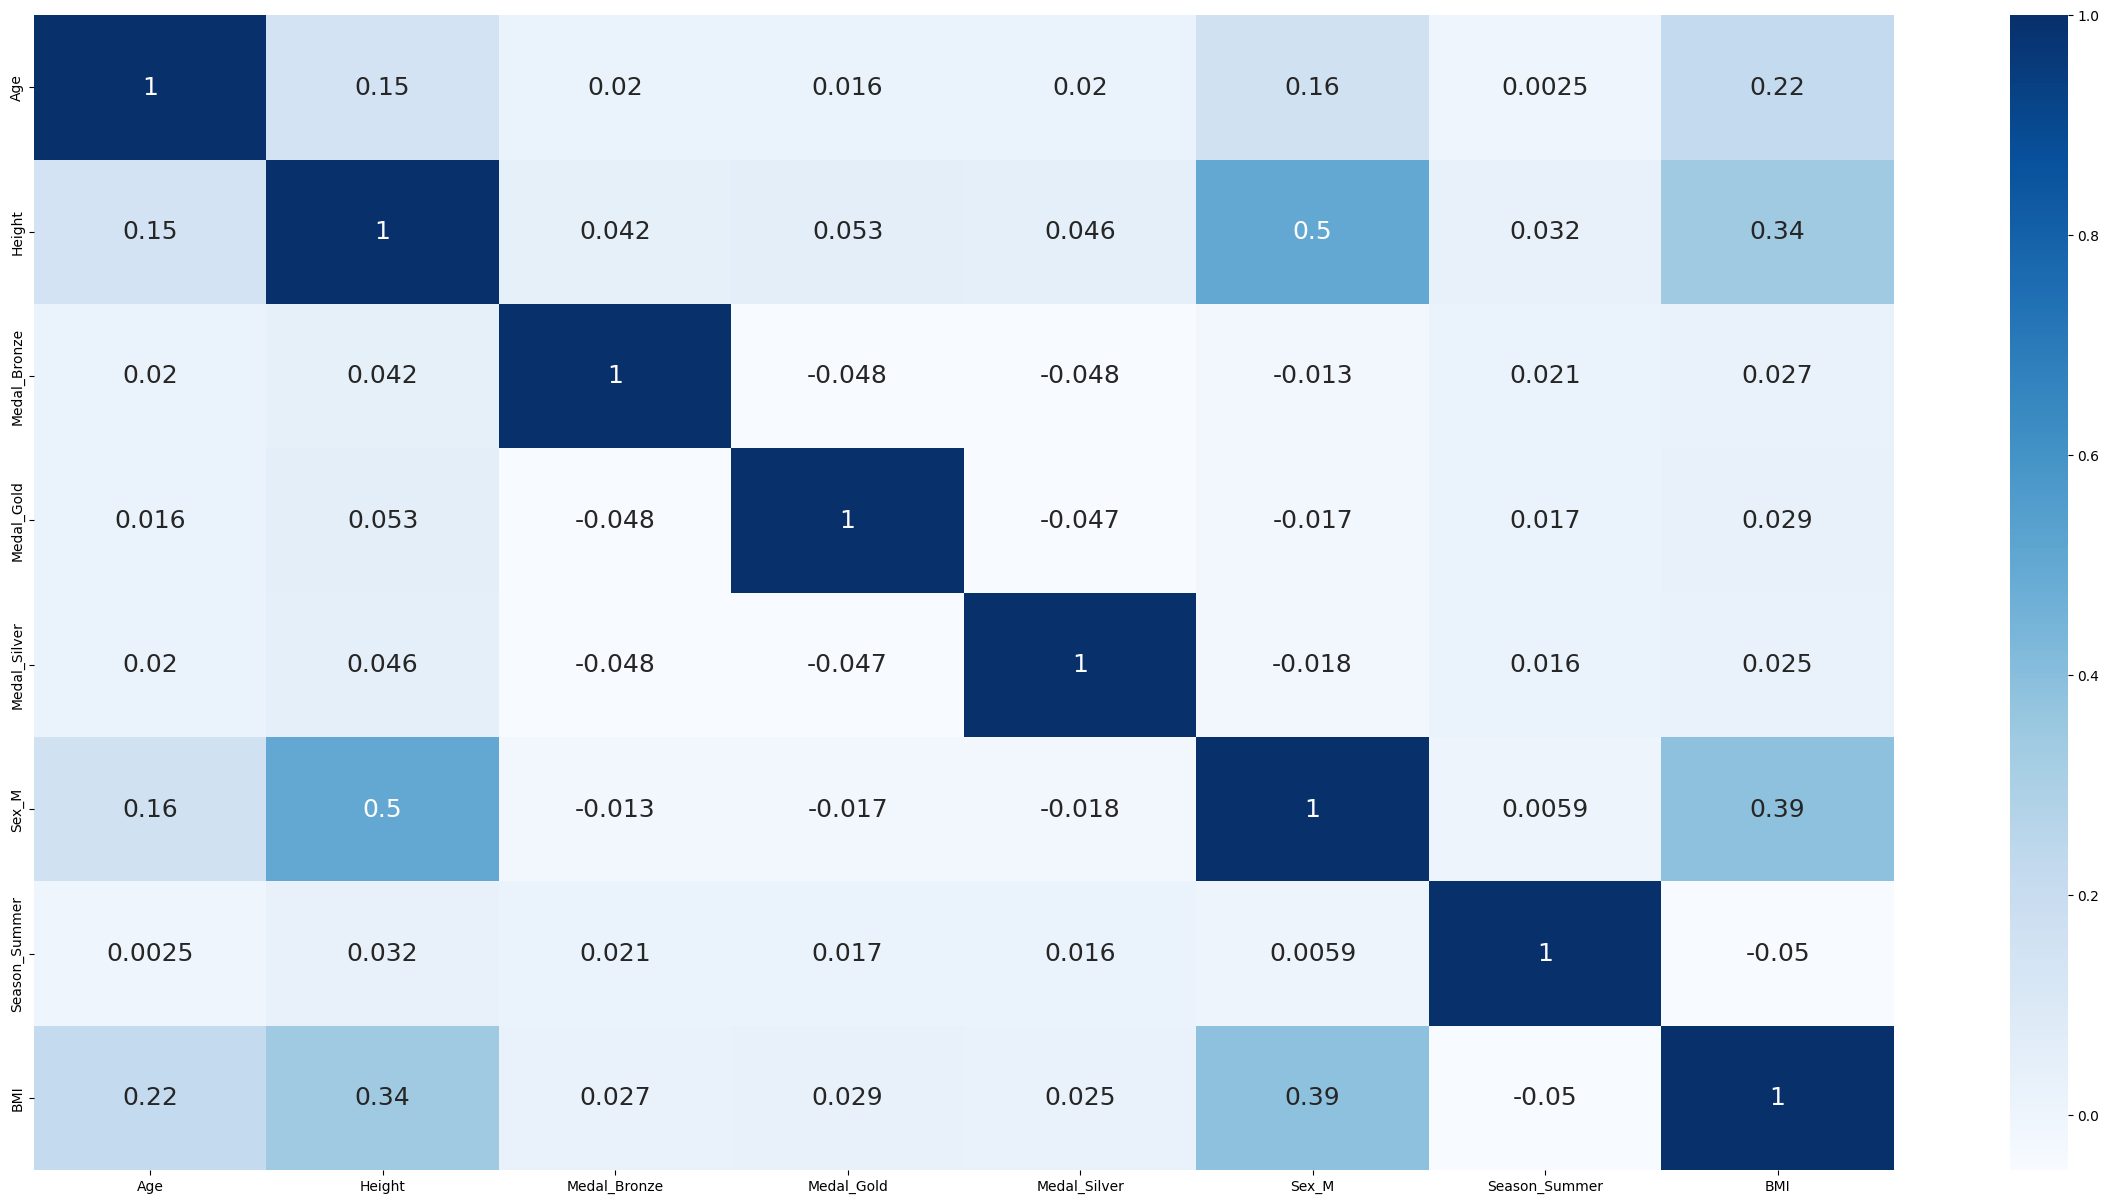

In [221]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(30,15))
ax = sns.heatmap(df_final[df_final.columns].corr(),cmap="Blues",annot=True,annot_kws={"size": 18})

Elbow method per trovare il numero ottimale di cluster

        Age    Height  Medal_Bronze  Medal_Gold  Medal_Silver  Sex_M  \
0  0.216667  0.535354             0           0             0      1   
1  0.200000  0.434343             0           0             0      1   
2  0.166667  0.585859             0           0             0      0   
3  0.166667  0.585859             0           0             0      0   
4  0.233333  0.585859             0           0             0      0   

   Season_Summer       BMI  
0              1  0.265695  
1              1  0.192094  
2              0  0.251982  
3              0  0.251982  
4              0  0.251982  


Text(0, 0.5, 'wcss')

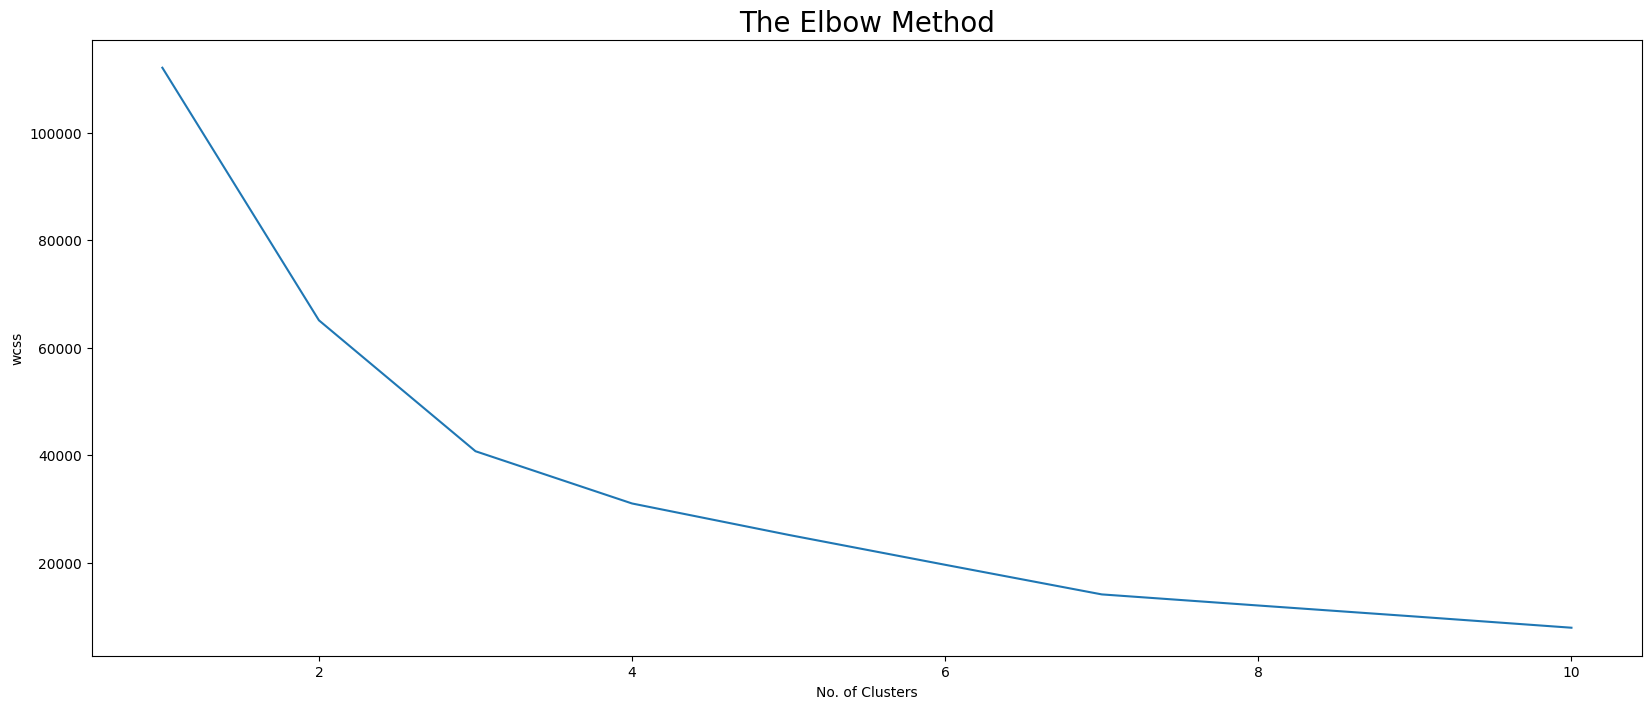

In [222]:
from sklearn.cluster import KMeans
print(df_final.head())
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    km.fit(df_final)
    wcss.append(km.inertia_)

plt.figure(figsize=(20,8))
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('wcss')

Visualizzazione Cluster

In [223]:
from sklearn.cluster import KMeans

k = 4
kmeans = KMeans(n_clusters = k, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)

cluster_labels = kmeans.fit_predict(df_final)

print(f"Modello K-Means con k={k} addestrato.")
print("Esempio delle prime 10 etichette assegnate:")
print(cluster_labels[:10])

df_cluster_1_final=df_final.copy()

df_cluster_1_final['Cluster_Fisico']=cluster_labels

print("\nDataFrame aggiornato con i nuovi cluster 'fisici':")
print(df_cluster_1_final.head())

analisi_finale = df_cluster_1_final.groupby('Cluster_Fisico').mean()

print("\n--- ANALISI FINALE DEI CLUSTER FISICI ---")
print(analisi_finale)


Modello K-Means con k=4 addestrato.
Esempio delle prime 10 etichette assegnate:
[1 1 3 3 3 3 3 3 0 0]

DataFrame aggiornato con i nuovi cluster 'fisici':
        Age    Height  Medal_Bronze  Medal_Gold  Medal_Silver  Sex_M  \
0  0.216667  0.535354             0           0             0      1   
1  0.200000  0.434343             0           0             0      1   
2  0.166667  0.585859             0           0             0      0   
3  0.166667  0.585859             0           0             0      0   
4  0.233333  0.585859             0           0             0      0   

   Season_Summer       BMI  Cluster_Fisico  
0              1  0.265695               1  
1              1  0.192094               1  
2              0  0.251982               3  
3              0  0.251982               3  
4              0  0.251982               3  

--- ANALISI FINALE DEI CLUSTER FISICI ---
                     Age    Height  Medal_Bronze  Medal_Gold  Medal_Silver  \
Cluster_Fisico        

Ci si accorge che i cluster sono "dominati" dalle feature categoriche Sex_M e Season_Summer, quindi rifacciamo l'analisi escludendole

        Age    Height  Medal_Bronze  Medal_Gold  Medal_Silver  Sex_M  \
0  0.216667  0.535354             0           0             0      1   
1  0.200000  0.434343             0           0             0      1   
2  0.166667  0.585859             0           0             0      0   
3  0.166667  0.585859             0           0             0      0   
4  0.233333  0.585859             0           0             0      0   

   Season_Summer       BMI  
0              1  0.265695  
1              1  0.192094  
2              0  0.251982  
3              0  0.251982  
4              0  0.251982  


Text(0, 0.5, 'wcss')

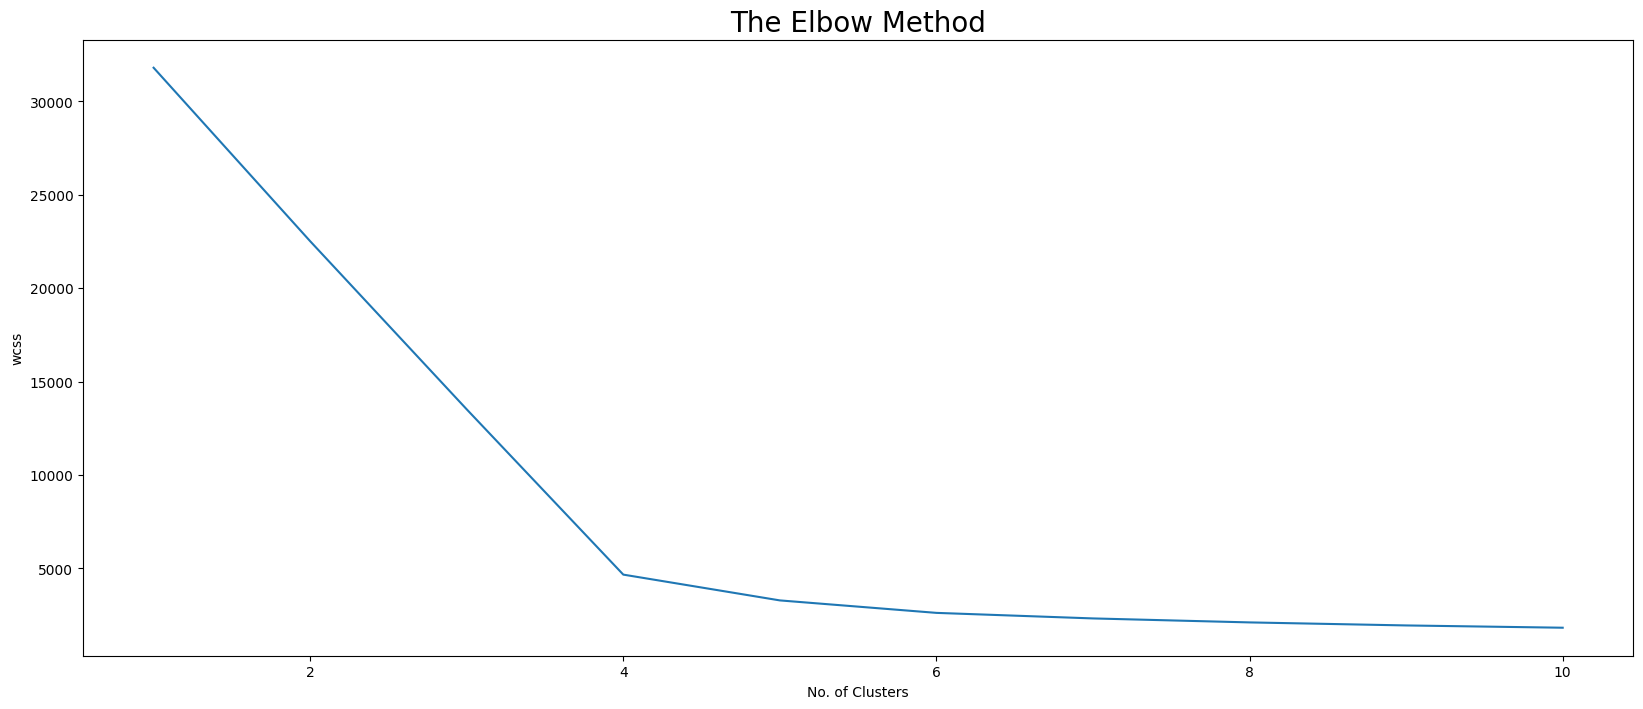

In [224]:
from sklearn.cluster import KMeans
print(df_final.head())
df_cluster_2=df_final.drop(columns=['Sex_M', 'Season_Summer'], errors='ignore')

wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    km.fit(df_cluster_2)
    wcss.append(km.inertia_)

plt.figure(figsize=(20,8))
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('wcss')

In [225]:
from sklearn.cluster import KMeans

k = 4
kmeans = KMeans(n_clusters = k, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)

cluster_labels = kmeans.fit_predict(df_cluster_2)

print(f"Modello K-Means con k={k} addestrato.")
print("Esempio delle prime 10 etichette assegnate:")
print(cluster_labels[:10])

df_cluster_2_final=df_final.copy()

df_cluster_2_final['Cluster_Fisico']=cluster_labels

print("\nDataFrame aggiornato con i nuovi cluster 'fisici':")
print(df_cluster_2_final.head())

analisi_finale = df_cluster_2_final.groupby('Cluster_Fisico').mean()

print("\n--- ANALISI FINALE DEI CLUSTER FISICI ---")
print(analisi_finale)



Modello K-Means con k=4 addestrato.
Esempio delle prime 10 etichette assegnate:
[1 1 1 1 1 1 1 1 1 1]

DataFrame aggiornato con i nuovi cluster 'fisici':
        Age    Height  Medal_Bronze  Medal_Gold  Medal_Silver  Sex_M  \
0  0.216667  0.535354             0           0             0      1   
1  0.200000  0.434343             0           0             0      1   
2  0.166667  0.585859             0           0             0      0   
3  0.166667  0.585859             0           0             0      0   
4  0.233333  0.585859             0           0             0      0   

   Season_Summer       BMI  Cluster_Fisico  
0              1  0.265695               1  
1              1  0.192094               1  
2              0  0.251982               1  
3              0  0.251982               1  
4              0  0.251982               1  

--- ANALISI FINALE DEI CLUSTER FISICI ---
                     Age    Height  Medal_Bronze  Medal_Gold  Medal_Silver  \
Cluster_Fisico        

Anche in questo caso si nota che le medaglie "dominano" i cluster, quindi si vanno ad eliminare anche esse

        Age    Height  Medal_Bronze  Medal_Gold  Medal_Silver  Sex_M  \
0  0.216667  0.535354             0           0             0      1   
1  0.200000  0.434343             0           0             0      1   
2  0.166667  0.585859             0           0             0      0   
3  0.166667  0.585859             0           0             0      0   
4  0.233333  0.585859             0           0             0      0   

   Season_Summer       BMI  
0              1  0.265695  
1              1  0.192094  
2              0  0.251982  
3              0  0.251982  
4              0  0.251982  
        Age    Height       BMI
0  0.216667  0.535354  0.265695
1  0.200000  0.434343  0.192094
2  0.166667  0.585859  0.251982
3  0.166667  0.585859  0.251982
4  0.233333  0.585859  0.251982


Text(0, 0.5, 'wcss')

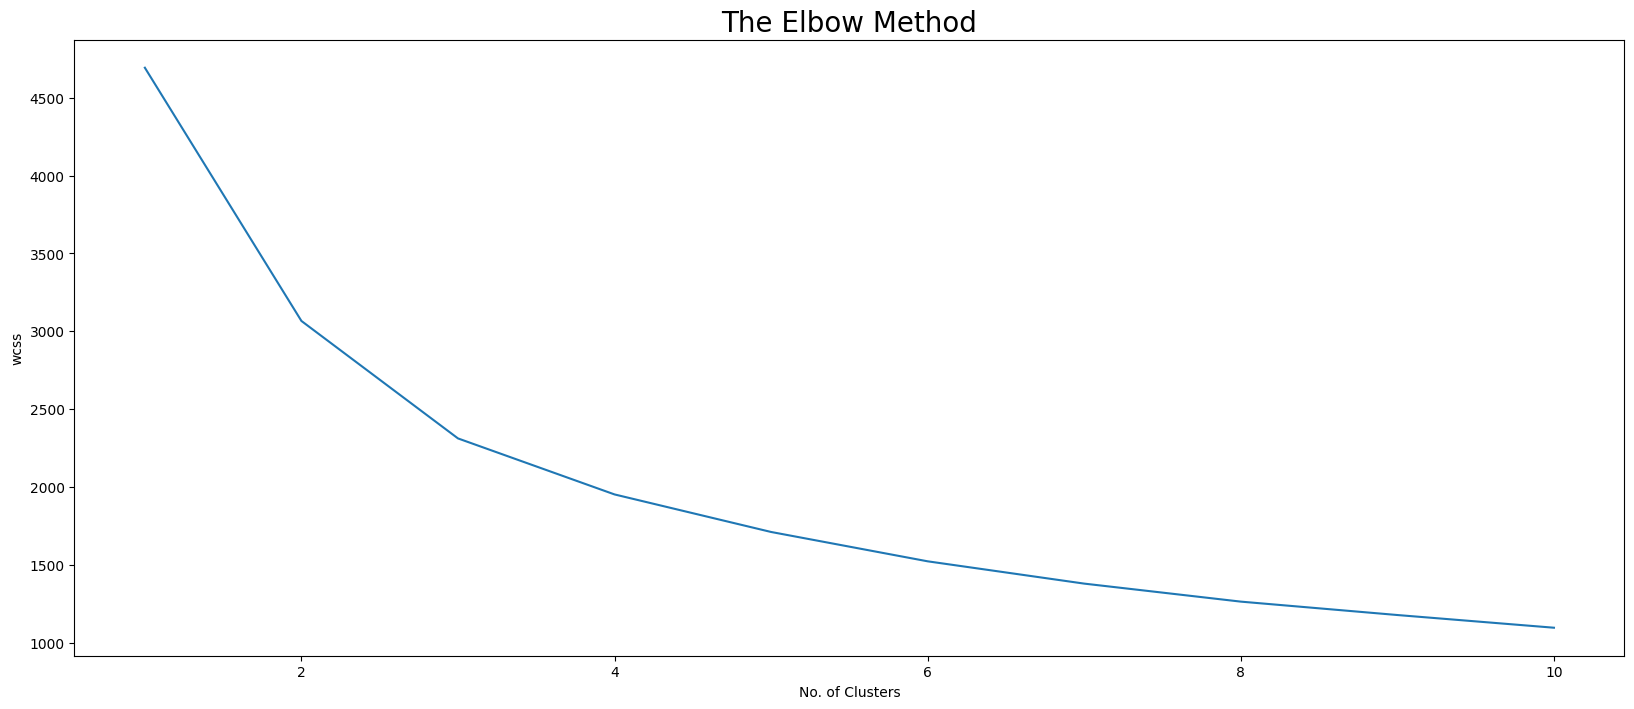

In [226]:
from sklearn.cluster import KMeans
print(df_final.head())
df_cluster_3=df_final.drop(columns=['Sex_M', 'Season_Summer','Medal_Gold','Medal_Silver','Medal_Bronze'], errors='ignore')
print(df_cluster_3.head())
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    km.fit(df_cluster_3)
    wcss.append(km.inertia_)

plt.figure(figsize=(20,8))
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('wcss')

In [227]:
from sklearn.cluster import KMeans

k = 4
kmeans = KMeans(n_clusters = k, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)

cluster_labels = kmeans.fit_predict(df_cluster_3)

print(f"Modello K-Means con k={k} addestrato.")
print("Esempio delle prime 10 etichette assegnate:")
print(cluster_labels[:10])

df_cluster_3_final=df_final.copy()

df_cluster_3_final['Cluster_Fisico'] = cluster_labels

print("\nDataFrame aggiornato con i nuovi cluster 'fisici':")
print(df_cluster_3_final.head())

analisi_finale = df_cluster_3_final.groupby('Cluster_Fisico').mean()

print("\n--- ANALISI FINALE DEI CLUSTER FISICI ---")
print(analisi_finale)

Modello K-Means con k=4 addestrato.
Esempio delle prime 10 etichette assegnate:
[3 0 1 1 1 1 1 1 1 1]

DataFrame aggiornato con i nuovi cluster 'fisici':
        Age    Height  Medal_Bronze  Medal_Gold  Medal_Silver  Sex_M  \
0  0.216667  0.535354             0           0             0      1   
1  0.200000  0.434343             0           0             0      1   
2  0.166667  0.585859             0           0             0      0   
3  0.166667  0.585859             0           0             0      0   
4  0.233333  0.585859             0           0             0      0   

   Season_Summer       BMI  Cluster_Fisico  
0              1  0.265695               3  
1              1  0.192094               0  
2              0  0.251982               1  
3              0  0.251982               1  
4              0  0.251982               1  

--- ANALISI FINALE DEI CLUSTER FISICI ---
                     Age    Height  Medal_Bronze  Medal_Gold  Medal_Silver  \
Cluster_Fisico        

Generazione del Pair Plot...
Grafico Pair Plot salvato come: cluster_pairplot.png


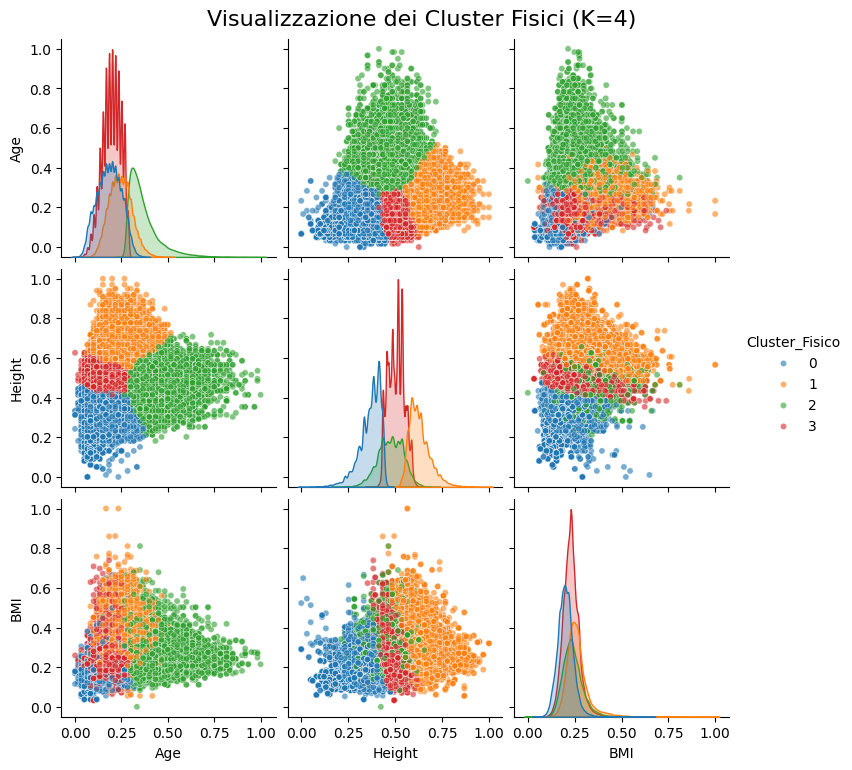

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assicurati che 'df_final' sia il tuo dataframe completo
# e 'Cluster_Fisico' sia la colonna con le etichette (0, 1, 2, 3)

print("Generazione del Pair Plot...")

# 1. È buona prassi convertire la colonna del cluster in 'category'
#    Questo assicura che Seaborn usi colori distinti e non una sfumatura.
df_cluster_3_final['Cluster_Fisico'] = df_cluster_3_final['Cluster_Fisico'].astype('category')

# 2. Crea il Pair Plot
pair_plot = sns.pairplot(
    df_cluster_3_final,
    # 'vars' sono le 3 colonne usate per creare i cluster
    vars=['Age', 'Height', 'BMI'], 
    # 'hue' è la colonna che definisce i colori
    hue='Cluster_Fisico',
    # Scegliamo una palette di colori chiara
    palette='tab10', 
    # Aggiungiamo trasparenza per vedere i punti sovrapposti
    plot_kws={'alpha': 0.6, 's': 20} 
)

# 3. Aggiungi un titolo
pair_plot.fig.suptitle('Visualizzazione dei Cluster Fisici (K=4)', y=1.02, fontsize=16)
